# JUSTIFICACIÓN MATEMÁTICA Y ESTADÍSTICA DEL MODELO PREDICTIVO

## 1. Análisis del Problema y Selección de Métricas
En este proyecto de predicción de impago (Credit Scoring), nos enfrentamos a un problema de clasificación binaria fuertemente condicionado por un **dataset desbalanceado** (muchos más clientes pagadores que morosos). 

### 1.1. El problema del desbalanceo y la falacia del Accuracy
En un entorno desbalanceado (ej. 90% pagadores, 10% morosos), un modelo "vago" que prediga siempre la clase mayoritaria obtendría un *Accuracy* del 90%. Sin embargo, su utilidad empresarial sería nula, ya que el coste de los Falsos Negativos (clasificar a un moroso como pagador) es económicamente devastador para la entidad financiera frente al coste de un Falso Positivo (denegar un crédito a un buen cliente).

Por ello, hemos modificado las probabilidades previas del modelo utilizando **SMOTE** (Synthetic Minority Over-sampling Technique) y el parámetro `class_weight="balanced"`. Esto fuerza al algoritmo matemático a penalizar severamente los errores sobre la clase minoritaria.

### 1.2. Función Objetivo y Métrica a Maximizar
Nuestra función objetivo a nivel de negocio es **minimizar el Riesgo de Crédito (Pérdida Esperada)**. Traducido a métricas estadísticas, esto significa que nuestra prioridad absoluta es **maximizar el Recall (Sensibilidad) de la clase 1 (Morosos)**.
* **Fórmula:** $Recall = \frac{TP}{TP + FN}$
* **Justificación:** Maximizar el Recall implica minimizar matemáticamente los $FN$ (Falsos Negativos). Preferimos sacrificar *Precision* (asumir más Falsos Positivos) si con ello garantizamos capturar a la inmensa mayoría de los verdaderos morosos. 
* **Umbral Dinámico:** Para lograr esto, no evaluamos las predicciones con el umbral clásico de $0.5$, sino que extraemos las probabilidades continuas ($P(Y=1|X)$) y buscamos el umbral probabilístico que maximice nuestro rendimiento dadas las condiciones del negocio (en nuestro torneo, este umbral se situó en torno a $0.42$).

## 2. Fundamentos Matemáticos del Árbol de Decisión (CART)
El modelo que ha demostrado un mejor equilibrio entre detección de morosos (Recall ~70%) y generalización (Gap de Overfitting casi nulo) ha sido el **Árbol de Decisión (Decision Tree Classifier)**.

### 2.1. Criterio de División (Splitting): La Impureza de Gini
La función objetivo interna del algoritmo CART (Classification and Regression Trees) en cada nodo es maximizar la Ganancia de Información, lo cual equivale a **minimizar la Impureza de Gini**.

La impureza de Gini en un nodo $m$ se define matemáticamente como:
$$Gini(m) = 1 - \sum_{k=1}^{C} p_{mk}^2$$
Donde $p_{mk}$ es la proporción de observaciones de la clase $k$ en el nodo $m$. Un Gini de $0$ indica pureza total (todos los clientes del nodo pertenecen a la misma clase).

El algoritmo evalúa todas las variables $j$ y todos los posibles puntos de corte $t$, buscando el par $(j, t)$ que minimice la impureza ponderada de los nodos hijos:
$$J(j, t) = \frac{n_{left}}{n_m} Gini(left) + \frac{n_{right}}{n_m} Gini(right)$$

### 2.2. Regularización mediante Poda Previa (max_depth=5)
Los árboles de decisión tienen una tendencia natural a sufrir varianza alta (Overfitting) porque el espacio de hipótesis es enorme. Si no se limitan, el árbol crecerá hasta que $Gini(m) = 0$ en todas sus hojas, memorizando el conjunto de entrenamiento.

Para forzar la generalización, hemos aplicado una **restricción matemática al espacio de búsqueda**: limitar la profundidad máxima (`max_depth = 5`). Esta "poda previa" obliga al modelo a seleccionar únicamente los splits que generan las mayores reducciones absolutas de impureza en las primeras etapas, ignorando el ruido estadístico de las ramificaciones más profundas.

In [ ]:
# ENTRENAMIENTO Y EXTRACCIÓN DEL ÁRBOL PARA ANÁLISIS MATEMÁTICO
import numpy as np
import pandas as pd
import os
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    recall_score,
    precision_score,   
    make_scorer,
    silhouette_score,
    precision_recall_curve,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples
)

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestCentroid

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import time

# 1. CARGAR DATOS
def cargar_y_preparar_datos(ruta_archivo):
    df = pd.read_excel(ruta_archivo)
    # Filtrar solo vivienda y copiar para evitar warnings
    df_viv = df[df['Proposito'].astype(str)
                .str.contains('Vivienda', case=False, na=False)].copy()
    # Label
    df_viv['Impago_Label'] = df_viv['Impago'].map({0:0, 1:1})
    return df_viv

# Ajusta esta ruta si es necesario
ruta_real = os.path.join('..', 'Datos', 'Limpios', 'información_préstamos_limpio.xlsx')

if os.path.exists(ruta_real):
    df = cargar_y_preparar_datos(ruta_real)
else:
    print(f" ATENCIÓN: No se encuentra el archivo en {ruta_real}")
    df = pd.DataFrame() 

# 2. DEFINIR X e y
if not df.empty:
    target_col = "Impago_Label"
    columnas_a_eliminar = ["ID", "Impago", "Prima", "Proposito"]

    y = df[target_col]
    X = df.drop(columns=[target_col])
    X = X.drop(columns=[col for col in columnas_a_eliminar if col in X.columns])

    # Eliminar alta cardinalidad
    high_card_cols = [col for col in X.columns if X[col].nunique() > 50]
    X = X.drop(columns=high_card_cols)

    # One-hot encoding
    cat_cols = X.select_dtypes(include="object").columns
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    X = X.astype("float32")
    
# 3. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Entrenando Decision Tree Óptimo (SMOTE=True, PCA=False, max_depth=5)...")
#Este es el mejor arbol que nos ha dado en el objetivo 3

# 1. Aplicamos SMOTE para el desbalanceo (Obligatorio matemáticamente) 
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 2. Entrenamos el Árbol
tree_model = DecisionTreeClassifier(
    max_depth=5, 
    class_weight="balanced", 
    random_state=42,
    criterion="gini" # Explicado en la celda anterior
)
tree_model.fit(X_train_sm, y_train_sm)

print("Árbol entrenado. Listo para la extracción de reglas.")

Entrenando Decision Tree Óptimo (SMOTE=True, PCA=False, max_depth=5)...
Árbol entrenado. Listo para la extracción de reglas.


## 3. Representación Gráfica e Interpretación de los Splits
A continuación, visualizamos la estructura matemática del árbol. En cada nodo podemos observar:
1. **La regla de decisión matemática** ($X_j \leq t$).
2. **El Gini actual** (nivel de impureza antes del split).
3. **Samples** (número de clientes afectados en el subconjunto).
4. **Value** (distribución de clases [Pagadores, Morosos]).

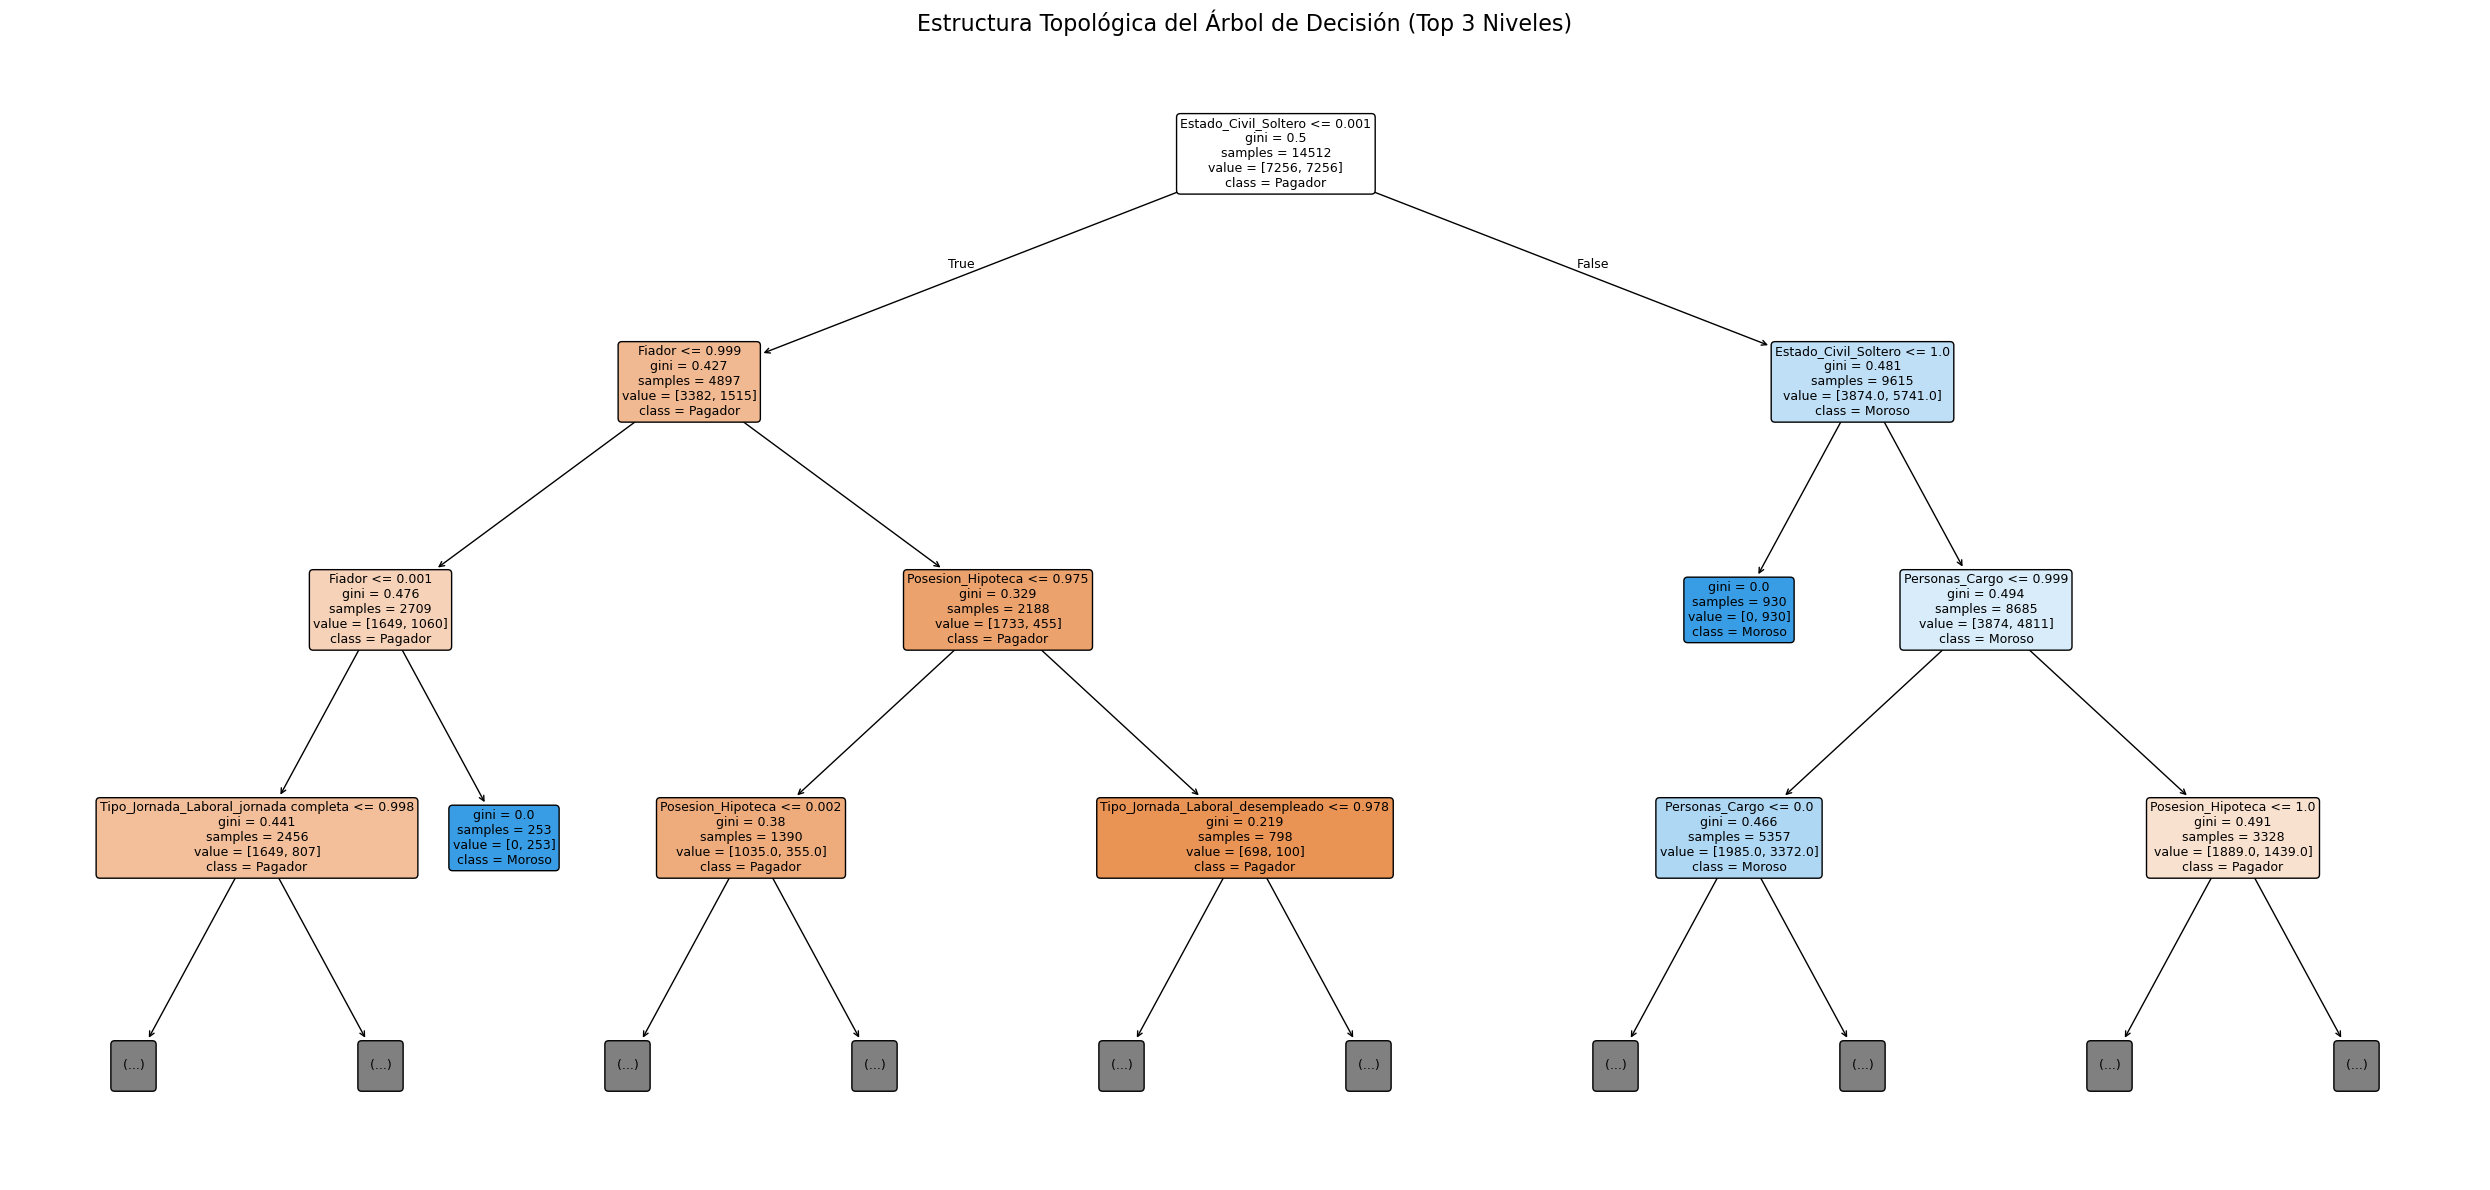

In [ ]:
# REPRESENTACIÓN GRÁFICA DEL ÁRBOL DE DECISIÓN
plt.figure(figsize=(25, 12)) # Tamaño grande para poder leer los nodos
plot_tree(
    tree_model, 
    feature_names=X_train.columns, 
    class_names=['Pagador', 'Moroso'], 
    filled=True, 
    rounded=True,
    fontsize=9,
    max_depth=3 # Mostramos solo los 3 primeros niveles para que sea legible en el PDF/Notebook
)
plt.title("Estructura Topológica del Árbol de Decisión (Top 3 Niveles)", fontsize=16)
plt.tight_layout()
plt.show()

**Plotly no tiene una función nativa para dibujar Árboles de Decisión clásicos (cajas y flechas). La función plot_tree que extrae las reglas matemáticas, el Gini y los umbrales de cada nodo pertenece exclusivamente a la librería scikit-learn, y está construida al 100% sobre Matplotlib.

## 4. Análisis de Reducción de Impureza (Feature Importance)
En los árboles CART, la importancia de una variable no se calcula por coeficientes (como en una Regresión Logística), sino por la **cantidad total de impureza de Gini que esa variable logra reducir** a lo largo de todos los nodos donde actúa como criterio de división, ponderada por la fracción de muestras que pasan por esos nodos.

Matemáticamente, la importancia de la variable $j$ es:
$$Importancia(j) = \sum_{m \in Nodos\_con\_j} p(m) \times \Delta Gini(m)$$

A continuación, calculamos y extraemos las variables que mayor reducción de impureza aportan al modelo:

In [ ]:
# CÁLCULO DE LA REDUCCIÓN DE IMPUREZA (FEATURE IMPORTANCE)

# Extraemos la importancia calculada internamente mediante reducción de Gini
importancias_gini = tree_model.feature_importances_

df_gini = pd.DataFrame({
    'Variable (Atributo)': X_train.columns,
    'Reducción de Impureza (Gini)': importancias_gini
}).sort_values(by='Reducción de Impureza (Gini)', ascending=True).tail(10) # Top 10

# Gráfico interactivo
fig_gini = px.bar(
    df_gini, 
    x='Reducción de Impureza (Gini)', 
    y='Variable (Atributo)', 
    orientation='h',
    title='Contribución Matemática de las Variables (Reducción de Gini)',
    color='Reducción de Impureza (Gini)',
    color_continuous_scale='Teal'
)
fig_gini.update_layout(template="plotly_white")
fig_gini.show()

print("\n INTERPRETACIÓN DEL NODO RAÍZ:")
variable_raiz = df_gini.iloc[-1]['Variable (Atributo)']
print(f"La variable '{variable_raiz}' es la que genera el primer split (el nodo raíz) porque es matemáticamente la que consigue la mayor caída de la impureza de Gini (Δ Gini) en el primer corte de todo el dataset.")


 INTERPRETACIÓN DEL NODO RAÍZ:
La variable 'Estado_Civil_Soltero' es la que genera el primer split (el nodo raíz) porque es matemáticamente la que consigue la mayor caída de la impureza de Gini (Δ Gini) en el primer corte de todo el dataset.
